# 04 — Allelic Dropout Filtering

Address the F_IS = 0.28 excess homozygosity by filtering dropout-affected markers.

**Inputs**: `data/geno_filtered.csv`, DArTseq SNP files (for marker metadata)
**Output**: `data/geno_dropout_filtered.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

## Load filtered genotypes and marker metadata

In [2]:
# Load QC-filtered genotypes from notebook 02
geno = pd.read_csv('../data/geno_filtered.csv', index_col=0)
print(f'Input genotype matrix: {geno.shape[0]:,} markers x {geno.shape[1]:,} samples')
print(f'Missing rate: {geno.isna().mean().mean():.3f}')

Input genotype matrix: 19,930 markers x 836 samples
Missing rate: 0.076


In [3]:
# Load marker metadata from DArTseq files to get depth info
def load_dart_meta(path, n_meta_cols=24):
    """Load marker metadata from a DArTseq SNP file (ref rows only)."""
    raw = pd.read_csv(path, header=6, low_memory=False)
    meta = raw.iloc[::2, :n_meta_cols].copy()  # ref rows only (even indices)
    meta = meta.set_index('AlleleID')
    return meta

meta_2 = load_dart_meta('../data/Report_DMo25-3087_SNP_2.csv')
meta_3 = load_dart_meta('../data/Report_DMo25-3087_SNP_3.csv')
marker_meta = pd.concat([meta_2, meta_3])

# Keep only markers that survived QC filtering
marker_meta = marker_meta.loc[marker_meta.index.intersection(geno.index)]
print(f'Marker metadata: {len(marker_meta):,} markers')
print(f'Columns: {list(marker_meta.columns)}')

Marker metadata: 19,930 markers
Columns: ['CloneID', 'AlleleSequence', 'TrimmedSequence', 'Chrom_VectorBase-68_AfunestusAfunGA1_Genome', 'ChromPosTag_VectorBase-68_AfunestusAfunGA1_Genome', 'ChromPosSnp_VectorBase-68_AfunestusAfunGA1_Genome', 'AlnCnt_VectorBase-68_AfunestusAfunGA1_Genome', 'AlnEvalue_VectorBase-68_AfunestusAfunGA1_Genome', 'Strand_VectorBase-68_AfunestusAfunGA1_Genome', 'SNP', 'SnpPosition', 'CallRate', 'OneRatioRef', 'OneRatioSnp', 'FreqHomRef', 'FreqHomSnp', 'FreqHets', 'PICRef', 'PICSnp', 'AvgPIC', 'AvgCountRef', 'AvgCountSnp', 'RepAvg']


## Compute per-marker F_IS

In [4]:
def compute_fis(geno_df):
    """Compute per-marker F_IS (inbreeding coefficient).
    
    F_IS = 1 - (observed heterozygosity / expected heterozygosity)
    Expected het = 2 * p * (1 - p) under HWE.
    """
    n_called = geno_df.notna().sum(axis=1)
    n_het = (geno_df == 1).sum(axis=1)
    n_alt = (geno_df == 2).sum(axis=1)
    
    # Allele frequency (alt allele)
    p = (n_het + 2 * n_alt) / (2 * n_called)
    
    # Observed and expected heterozygosity
    h_obs = n_het / n_called
    h_exp = 2 * p * (1 - p)
    
    # F_IS
    fis = 1 - (h_obs / h_exp)
    fis = fis.replace([np.inf, -np.inf], np.nan)
    
    return pd.DataFrame({
        'fis': fis,
        'h_obs': h_obs,
        'h_exp': h_exp,
        'p': p,
        'n_called': n_called,
        'n_het': n_het,
    })

stats = compute_fis(geno)
print(f'Pre-filter F_IS summary:')
print(stats['fis'].describe())

Pre-filter F_IS summary:
count    19930.000000
mean         0.282500
std          0.237405
min         -0.341408
25%          0.071045
50%          0.235139
75%          0.478204
max          1.000000
Name: fis, dtype: float64


## Explore depth vs dropout relationship

In [5]:
# Merge marker depth info with F_IS stats
depth_cols = ['AvgCountRef', 'AvgCountSnp']
for col in depth_cols:
    marker_meta[col] = pd.to_numeric(marker_meta[col], errors='coerce')

stats = stats.join(marker_meta[depth_cols], how='left')
stats['avg_depth'] = (stats['AvgCountRef'].fillna(0) + stats['AvgCountSnp'].fillna(0)) / 2

print(f'Average read depth per marker:')
print(stats['avg_depth'].describe())

Average read depth per marker:
count    19930.000000
mean        23.060085
std         19.629801
min          2.616475
25%          7.168469
50%         16.010623
75%         34.769444
max        146.915035
Name: avg_depth, dtype: float64


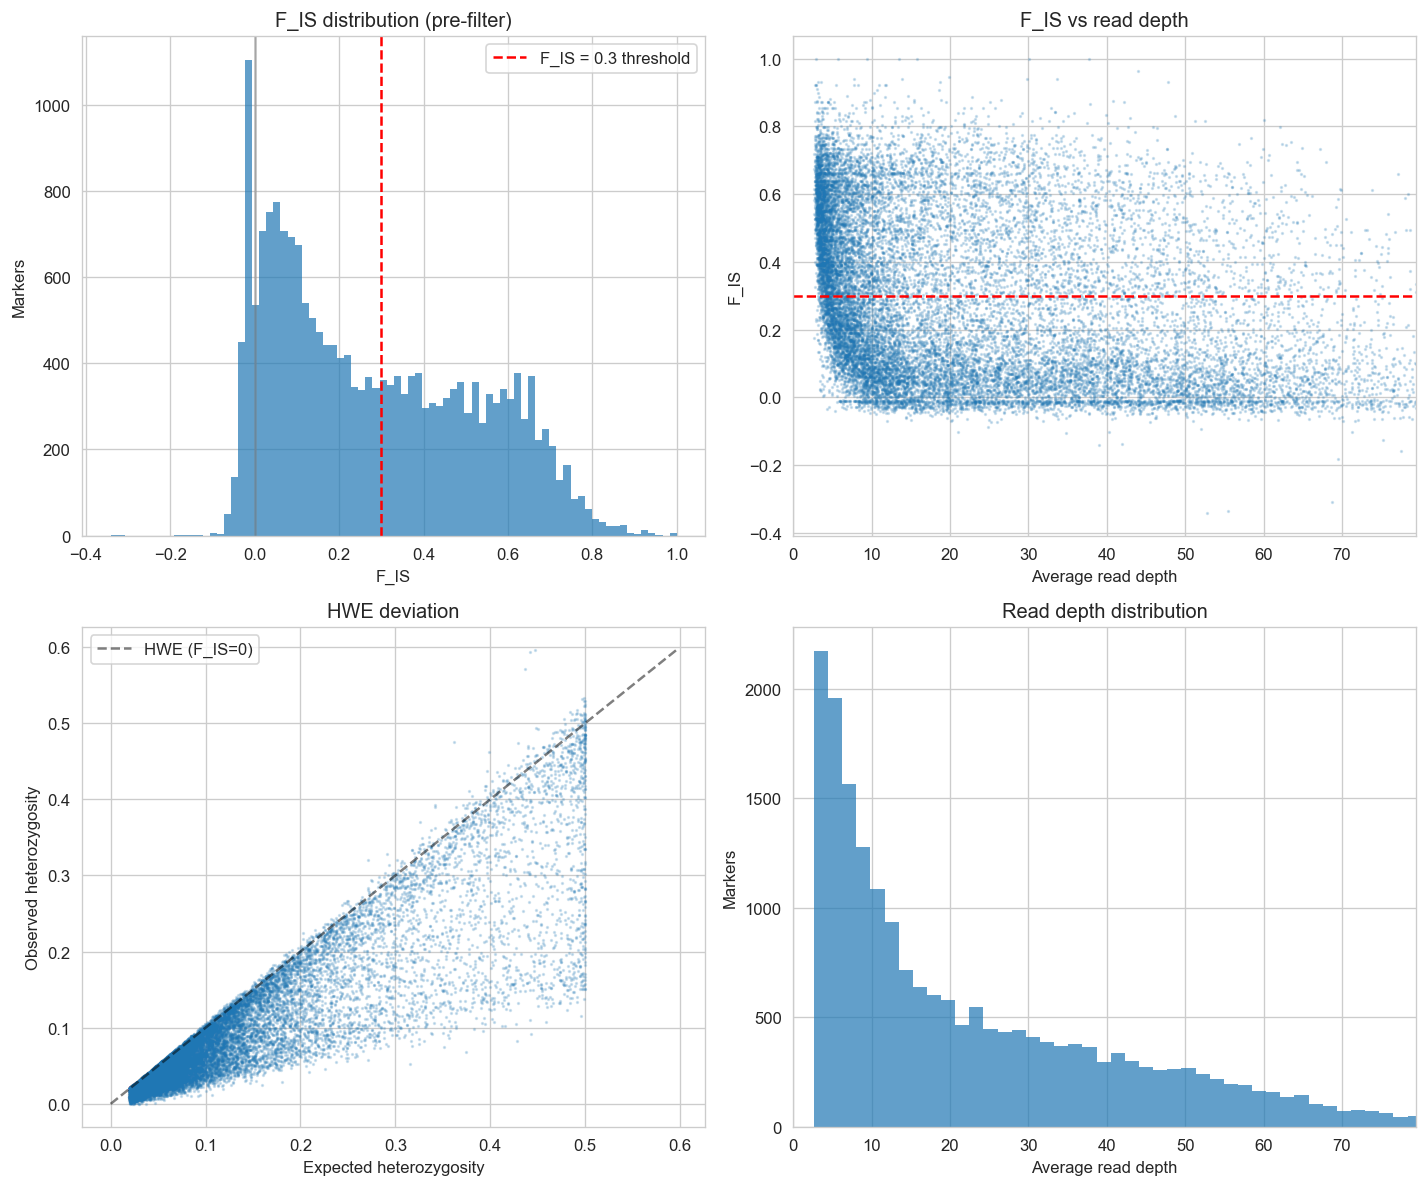

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# F_IS distribution
ax = axes[0, 0]
ax.hist(stats['fis'].dropna(), bins=80, edgecolor='none', alpha=0.7)
ax.axvline(0.3, color='red', ls='--', label='F_IS = 0.3 threshold')
ax.axvline(0, color='grey', ls='-', alpha=0.5)
ax.set_xlabel('F_IS')
ax.set_ylabel('Markers')
ax.set_title('F_IS distribution (pre-filter)')
ax.legend()

# F_IS vs average depth
ax = axes[0, 1]
valid = stats.dropna(subset=['fis', 'avg_depth'])
ax.scatter(valid['avg_depth'], valid['fis'], s=1, alpha=0.2)
ax.axhline(0.3, color='red', ls='--')
ax.set_xlabel('Average read depth')
ax.set_ylabel('F_IS')
ax.set_title('F_IS vs read depth')
ax.set_xlim(0, valid['avg_depth'].quantile(0.99))

# Observed vs expected heterozygosity
ax = axes[1, 0]
ax.scatter(stats['h_exp'], stats['h_obs'], s=1, alpha=0.2)
lim = max(stats['h_exp'].max(), stats['h_obs'].max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.5, label='HWE (F_IS=0)')
ax.set_xlabel('Expected heterozygosity')
ax.set_ylabel('Observed heterozygosity')
ax.set_title('HWE deviation')
ax.legend()

# Read depth distribution
ax = axes[1, 1]
ax.hist(stats['avg_depth'].dropna(), bins=80, edgecolor='none', alpha=0.7)
ax.set_xlabel('Average read depth')
ax.set_ylabel('Markers')
ax.set_title('Read depth distribution')
ax.set_xlim(0, stats['avg_depth'].quantile(0.99))

plt.tight_layout()
plt.savefig('../results/fig_dropout_filtering.png', dpi=150, bbox_inches='tight')
plt.show()

## Apply F_IS filter

In [7]:
FIS_MAX = 0.3

mask_fis = stats['fis'] <= FIS_MAX
n_before = len(geno)
geno_fis = geno.loc[mask_fis[mask_fis].index.intersection(geno.index)]
n_after = len(geno_fis)

print(f'F_IS filter (F_IS <= {FIS_MAX}):')
print(f'  Before: {n_before:,} markers')
print(f'  After:  {n_after:,} markers')
print(f'  Removed: {n_before - n_after:,} markers ({(n_before - n_after)/n_before*100:.1f}%)')

F_IS filter (F_IS <= 0.3):
  Before: 19,930 markers
  After:  11,357 markers
  Removed: 8,573 markers (43.0%)


## Recalculate statistics on filtered data

In [8]:
stats_post = compute_fis(geno_fis)

print('Post-filter summary:')
print(f'  Markers: {len(geno_fis):,}')
print(f'  Samples: {geno_fis.shape[1]:,}')
print(f'  Missing rate: {geno_fis.isna().mean().mean():.3f}')
print(f'  Mean F_IS: {stats_post["fis"].mean():.3f}')
print(f'  Median F_IS: {stats_post["fis"].median():.3f}')
print(f'  Mean H_obs: {stats_post["h_obs"].mean():.4f}')
print(f'  Mean H_exp: {stats_post["h_exp"].mean():.4f}')

Post-filter summary:
  Markers: 11,357
  Samples: 836
  Missing rate: 0.018
  Mean F_IS: 0.102
  Median F_IS: 0.088
  Mean H_obs: 0.1154
  Mean H_exp: 0.1283


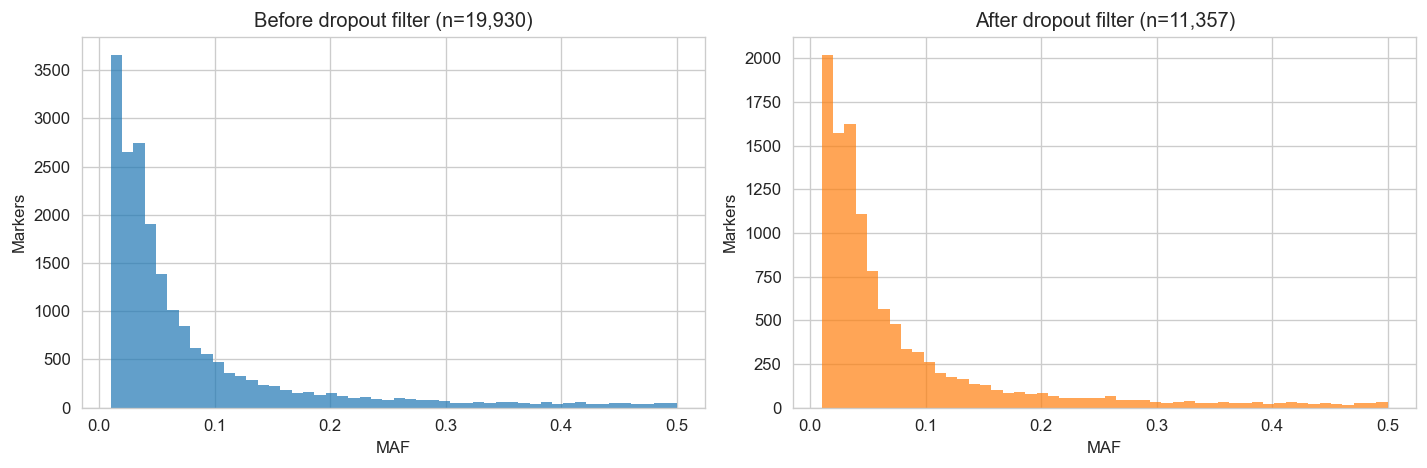

In [9]:
# Compare allele frequency spectra before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
p_before = stats['p']
maf_before = np.minimum(p_before, 1 - p_before)
axes[0].hist(maf_before.dropna(), bins=50, edgecolor='none', alpha=0.7)
axes[0].set_xlabel('MAF')
axes[0].set_ylabel('Markers')
axes[0].set_title(f'Before dropout filter (n={len(geno):,})')

# After
p_after = stats_post['p']
maf_after = np.minimum(p_after, 1 - p_after)
axes[1].hist(maf_after.dropna(), bins=50, edgecolor='none', alpha=0.7, color='C1')
axes[1].set_xlabel('MAF')
axes[1].set_ylabel('Markers')
axes[1].set_title(f'After dropout filter (n={len(geno_fis):,})')

plt.tight_layout()
plt.savefig('../results/fig_dropout_sfs.png', dpi=150, bbox_inches='tight')
plt.show()

Call-rate / het correlation BEFORE: r = 0.753
Call-rate / het correlation AFTER:  r = 0.771


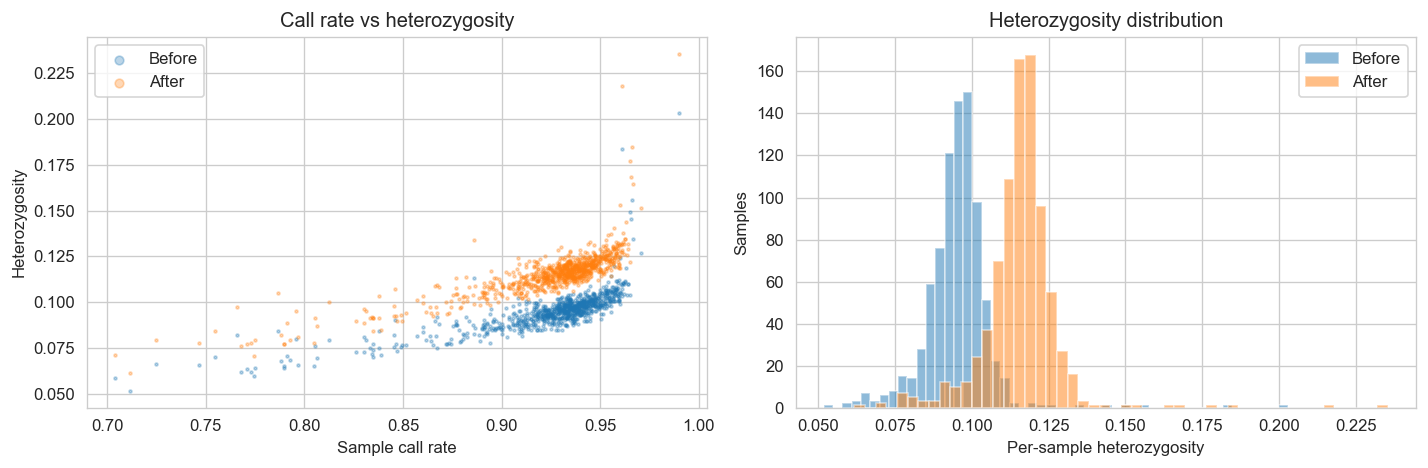

In [10]:
# Per-sample heterozygosity before and after
het_before = (geno == 1).sum(axis=0) / geno.notna().sum(axis=0)
het_after = (geno_fis == 1).sum(axis=0) / geno_fis.notna().sum(axis=0)
cr_before = geno.notna().mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(cr_before, het_before, s=3, alpha=0.3, label='Before')
axes[0].scatter(cr_before, het_after, s=3, alpha=0.3, label='After')
axes[0].set_xlabel('Sample call rate')
axes[0].set_ylabel('Heterozygosity')
axes[0].set_title('Call rate vs heterozygosity')
axes[0].legend(markerscale=3)

axes[1].hist(het_before, bins=50, alpha=0.5, label='Before')
axes[1].hist(het_after, bins=50, alpha=0.5, label='After')
axes[1].set_xlabel('Per-sample heterozygosity')
axes[1].set_ylabel('Samples')
axes[1].set_title('Heterozygosity distribution')
axes[1].legend()

from scipy.stats import pearsonr
r_before, _ = pearsonr(cr_before, het_before)
r_after, _ = pearsonr(cr_before, het_after)
print(f'Call-rate / het correlation BEFORE: r = {r_before:.3f}')
print(f'Call-rate / het correlation AFTER:  r = {r_after:.3f}')

plt.tight_layout()
plt.savefig('../results/fig_dropout_het.png', dpi=150, bbox_inches='tight')
plt.show()

## Save dropout-filtered genotypes

In [11]:
geno_fis.to_csv('../data/geno_dropout_filtered.csv')
print(f'Saved: data/geno_dropout_filtered.csv')
print(f'  Shape: {geno_fis.shape[0]:,} markers x {geno_fis.shape[1]:,} samples')

Saved: data/geno_dropout_filtered.csv
  Shape: 11,357 markers x 836 samples
